# 02 — EDA: PLD (Preço de Liquidação das Diferenças)

Exploratory data analysis of the Brazilian spot price across all 4 subsystems.

**Sections**
1. Load bronze PLD data
2. Time series overview (all 4 subsystems)
3. Distribution analysis
4. Autocorrelation & seasonality
5. Price spike analysis
6. Cross-subsystem correlation
7. PLD_min / PLD_max regulatory bounds

In [2]:
import duckdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from pathlib import Path

ROOT = Path("..")
sns.set_theme(style="whitegrid", palette="tab10")
plt.rcParams["figure.dpi"] = 130

## 1. Load Bronze PLD Data

In [3]:
con = duckdb.connect()
pld_path = ROOT / "data" / "bronze" / "pld.parquet"

if not pld_path.exists():
    print("Bronze PLD not found — run etl/run_pipeline.py first (or notebook 01).")
else:
    pld = con.execute(f"SELECT * FROM read_parquet('{pld_path}') ORDER BY week_start, subsystem").fetchdf()
    print(f"Shape: {pld.shape}")
    print(f"Date range: {pld['week_start'].min()} → {pld['week_start'].max()}")
    print(f"Subsystems: {pld['subsystem'].unique().tolist()}")
    pld.head()

Shape: (4172, 3)
Date range: 2005-01-07 00:00:00 → 2024-12-27 00:00:00
Subsystems: ['N', 'NE', 'S', 'SE/CO']


## 2. Time Series Overview

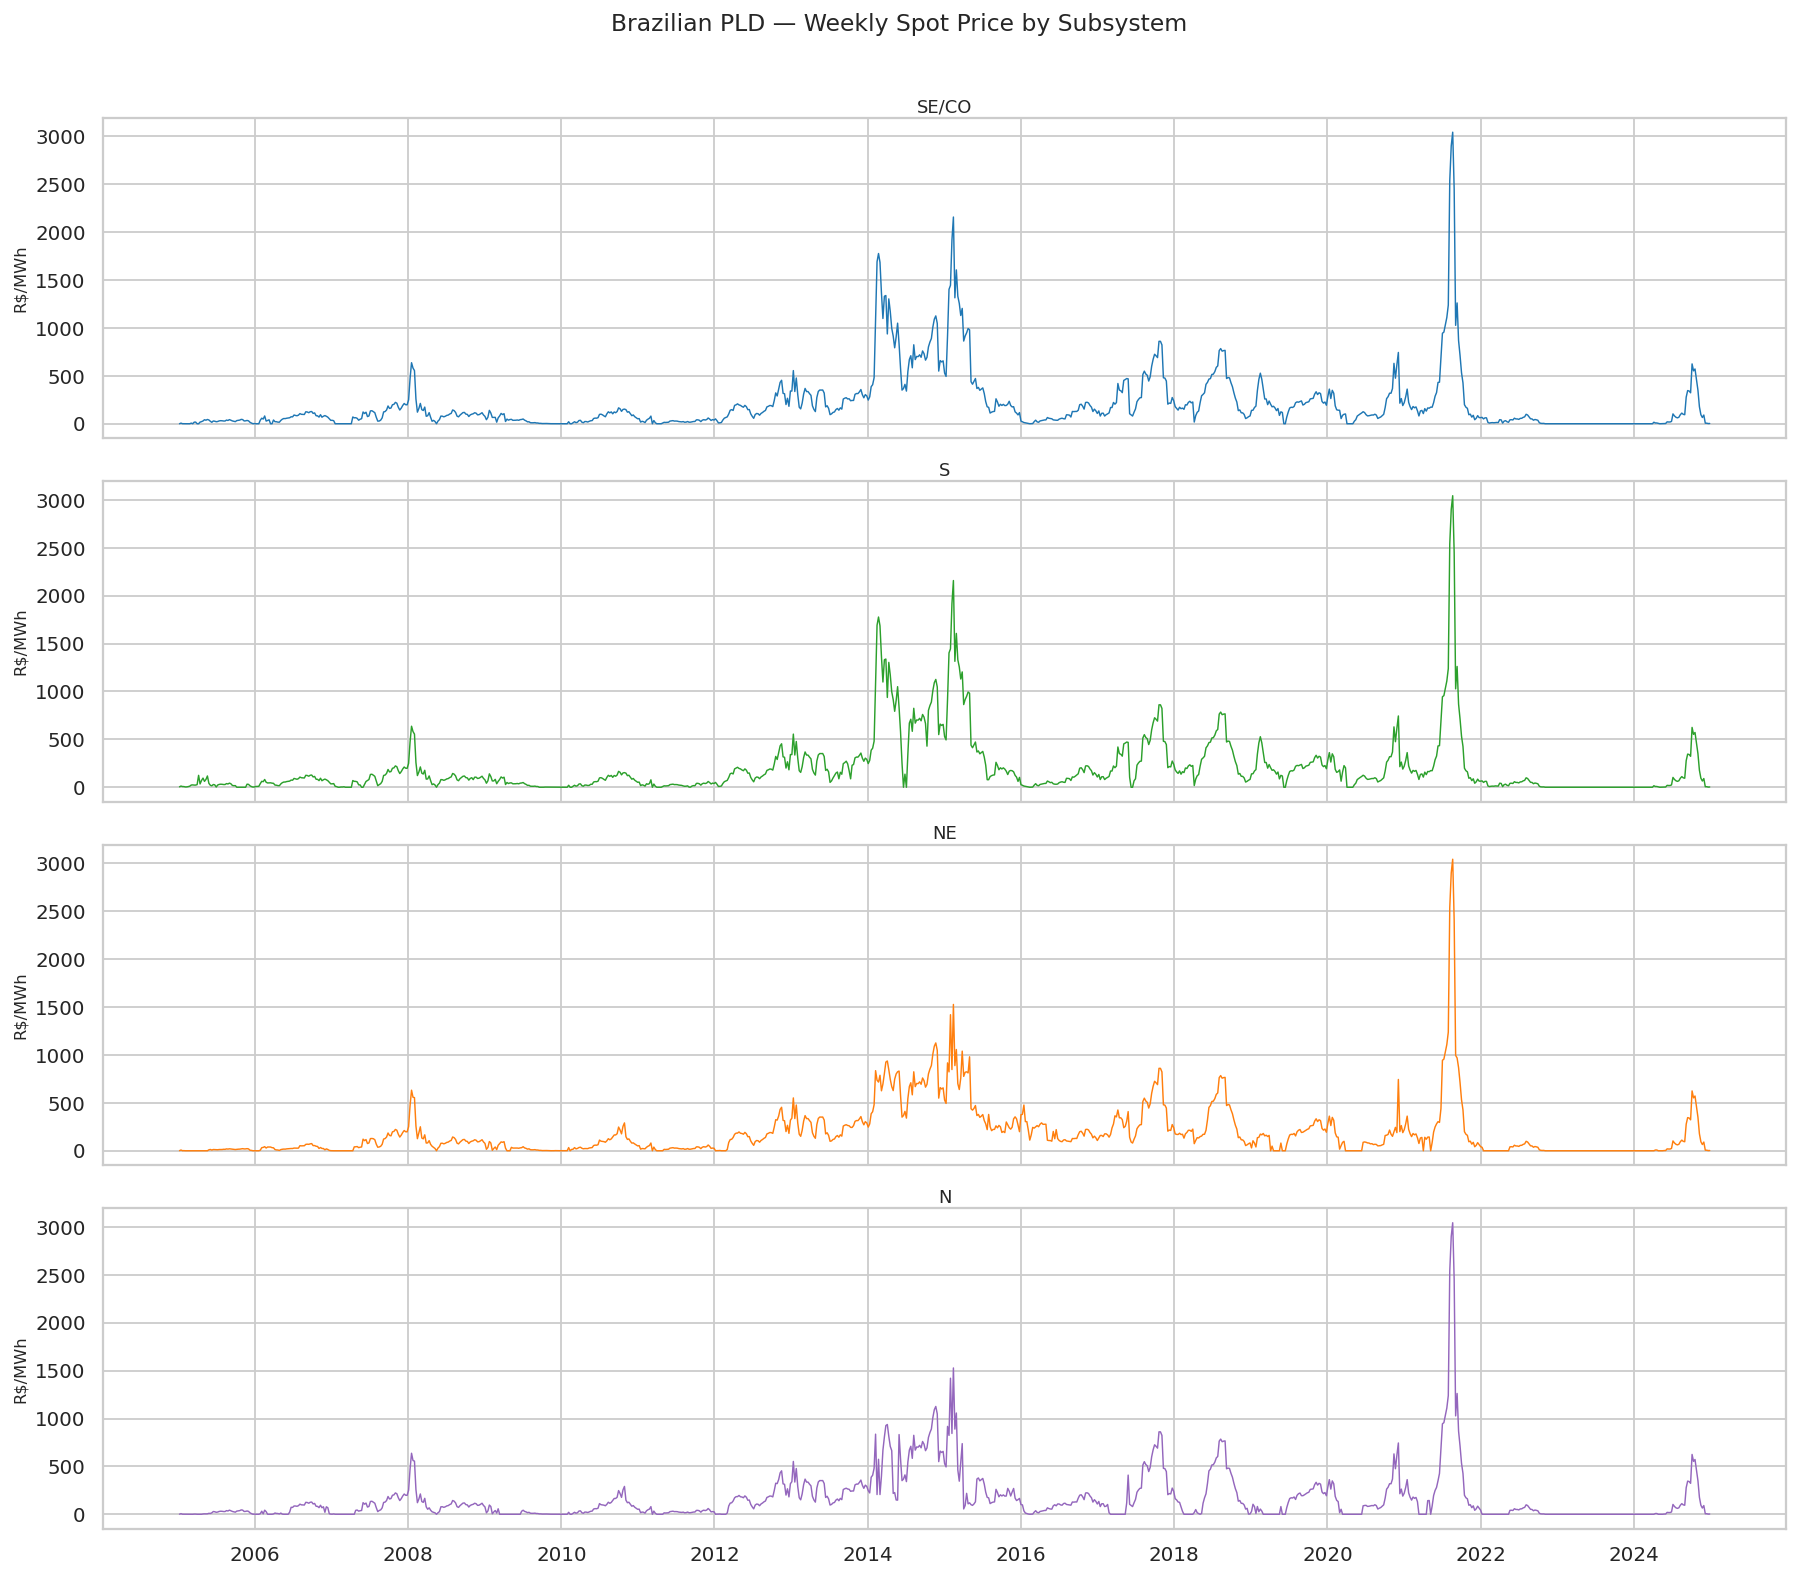

In [4]:
fig, axes = plt.subplots(4, 1, figsize=(14, 12), sharex=True)
subsystems = ["SE/CO", "S", "NE", "N"]
colors = ["#1f77b4", "#2ca02c", "#ff7f0e", "#9467bd"]

for ax, sub, color in zip(axes, subsystems, colors):
    data = pld[pld["subsystem"] == sub].sort_values("week_start")
    ax.plot(data["week_start"], data["pld_brl_mwh"], color=color, linewidth=0.8)
    ax.set_ylabel("R$/MWh", fontsize=9)
    ax.set_title(f"{sub}", fontsize=10, pad=3)
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    ax.xaxis.set_major_locator(mdates.YearLocator(2))

plt.suptitle("Brazilian PLD — Weekly Spot Price by Subsystem", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

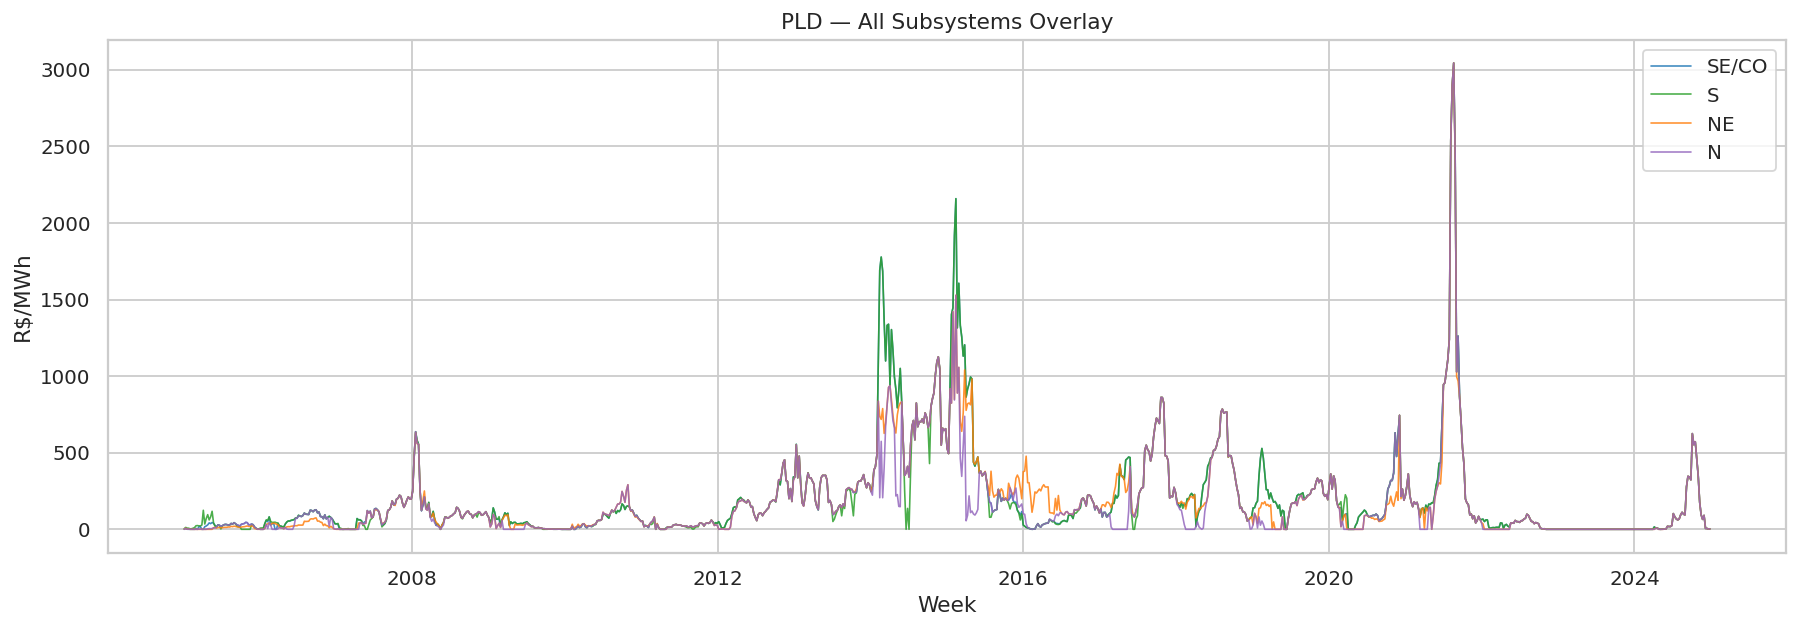

In [5]:
# All subsystems on a single chart for comparison
fig, ax = plt.subplots(figsize=(14, 5))

for sub, color in zip(subsystems, colors):
    data = pld[pld["subsystem"] == sub].sort_values("week_start")
    ax.plot(data["week_start"], data["pld_brl_mwh"], color=color, linewidth=0.9, label=sub, alpha=0.85)

ax.legend()
ax.set_xlabel("Week")
ax.set_ylabel("R$/MWh")
ax.set_title("PLD — All Subsystems Overlay")
plt.tight_layout()
plt.show()

## 3. Distribution Analysis

/tmp/ipykernel_174202/930603511.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[1].boxplot(plot_data, labels=subsystems, patch_artist=True)


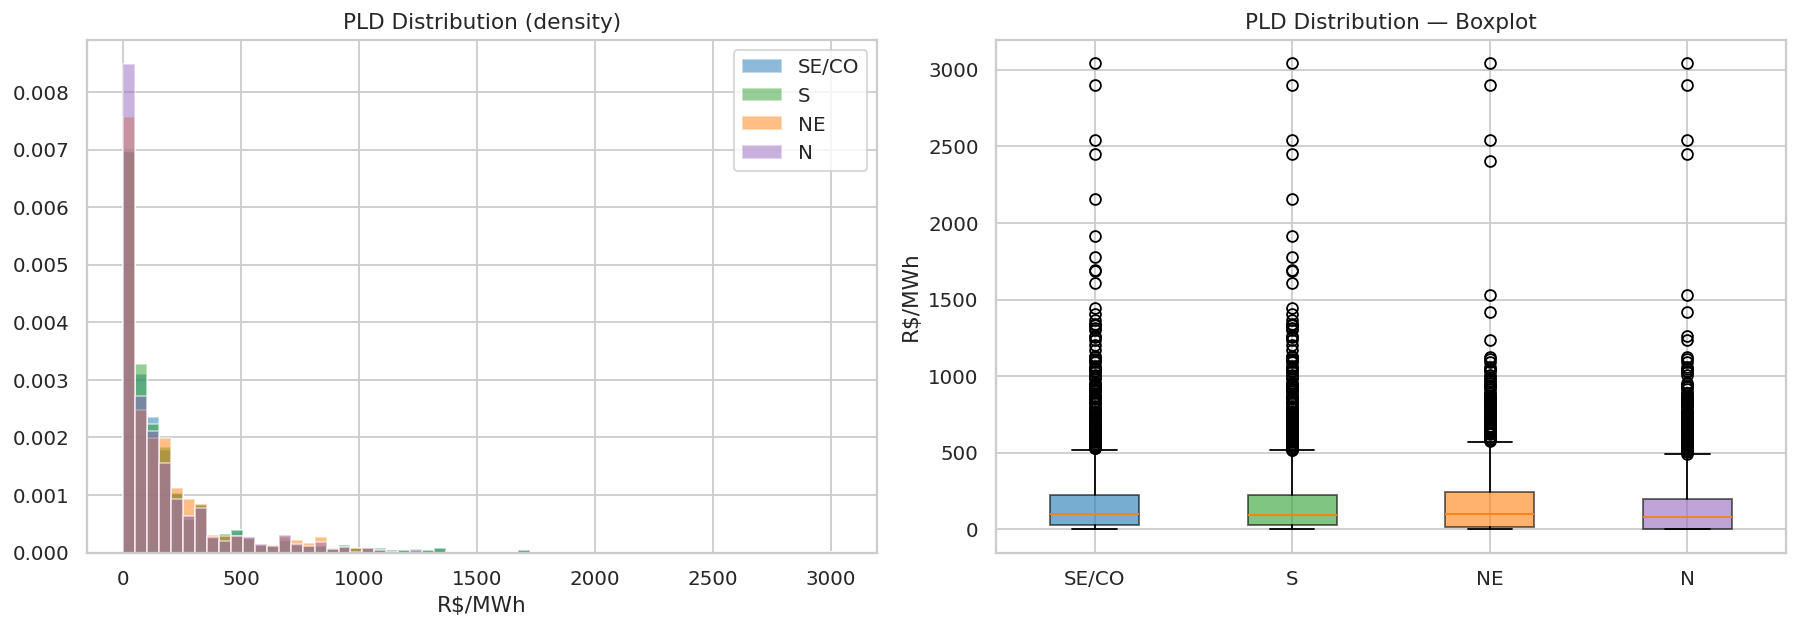

,count,mean,std,min,25%,50%,75%,max
subsystem,,,,,,,,
N,1043.0,166.47,274.53,0.0,3.34,81.88,198.69,3044.45
NE,1043.0,187.61,280.34,0.0,16.60,98.83,240.76,3044.45
S,1043.0,201.01,319.54,0.0,27.09,94.82,222.42,3044.45
SE/CO,1043.0,203.42,319.76,0.0,28.28,98.26,224.74,3044.45


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
for sub, color in zip(subsystems, colors):
    data = pld[pld["subsystem"] == sub]["pld_brl_mwh"]
    axes[0].hist(data, bins=60, alpha=0.5, color=color, label=sub, density=True)
axes[0].set_title("PLD Distribution (density)")
axes[0].set_xlabel("R$/MWh")
axes[0].legend()

# Box plot
plot_data = [pld[pld["subsystem"] == sub]["pld_brl_mwh"].values for sub in subsystems]
bp = axes[1].boxplot(plot_data, labels=subsystems, patch_artist=True)
for patch, color in zip(bp["boxes"], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)
axes[1].set_title("PLD Distribution — Boxplot")
axes[1].set_ylabel("R$/MWh")

plt.tight_layout()
plt.show()

# Summary statistics
pld.groupby("subsystem")["pld_brl_mwh"].describe().round(2)

## 4. Autocorrelation & Seasonality

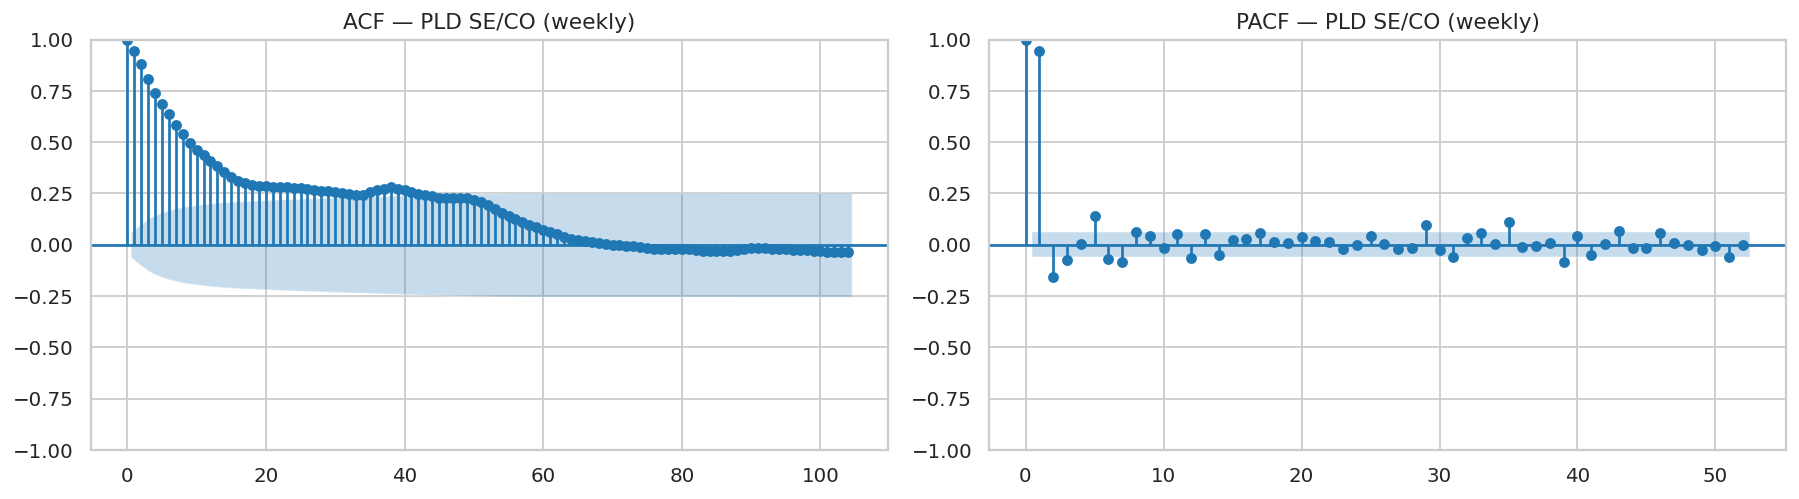

In [7]:
# ACF/PACF for SE/CO (most liquid subsystem)
seco = pld[pld["subsystem"] == "SE/CO"].sort_values("week_start")["pld_brl_mwh"].dropna()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_acf(seco, lags=104, ax=axes[0])   # 2 years of weekly lags
plot_pacf(seco, lags=52, ax=axes[1])   # 1 year
axes[0].set_title("ACF — PLD SE/CO (weekly)")
axes[1].set_title("PACF — PLD SE/CO (weekly)")
plt.tight_layout()
plt.show()

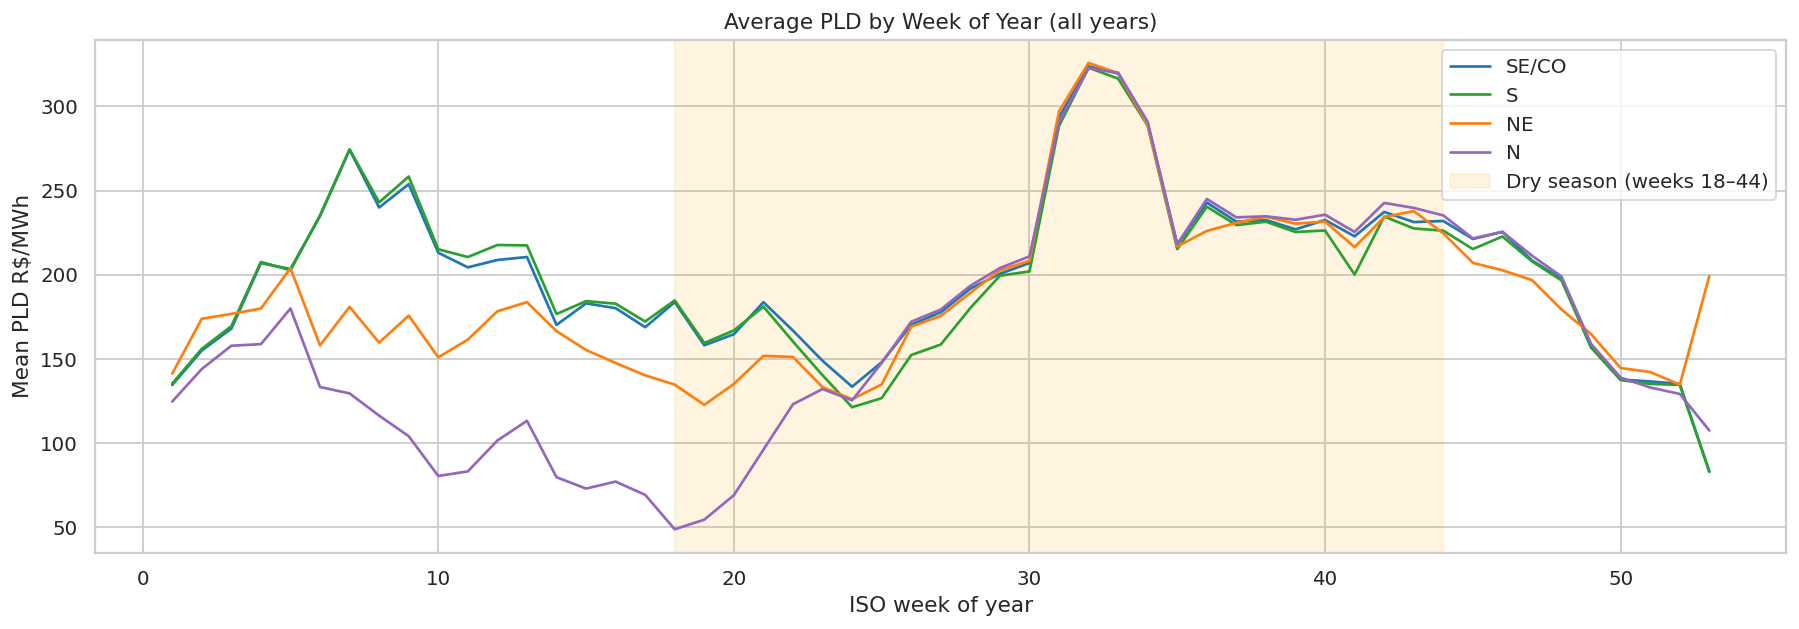

In [8]:
# Intra-year seasonality — average PLD by week of year
pld["week_of_year"] = pd.to_datetime(pld["week_start"]).dt.isocalendar().week.astype(int)
season = pld.groupby(["week_of_year", "subsystem"])["pld_brl_mwh"].mean().reset_index()

fig, ax = plt.subplots(figsize=(14, 5))
for sub, color in zip(subsystems, colors):
    d = season[season["subsystem"] == sub].sort_values("week_of_year")
    ax.plot(d["week_of_year"], d["pld_brl_mwh"], color=color, linewidth=1.5, label=sub)

ax.axvspan(18, 44, alpha=0.12, color="orange", label="Dry season (weeks 18–44)")
ax.set_xlabel("ISO week of year")
ax.set_ylabel("Mean PLD R$/MWh")
ax.set_title("Average PLD by Week of Year (all years)")
ax.legend()
plt.tight_layout()
plt.show()

## 5. Price Spike Analysis

In [9]:
# Define spikes as weeks where any subsystem exceeds the 90th percentile
p90 = pld.groupby("subsystem")["pld_brl_mwh"].transform(lambda x: x.quantile(0.90))
spikes = pld[pld["pld_brl_mwh"] > p90].copy()

print(f"Spike weeks (>P90 per subsystem): {spikes['week_start'].nunique()} weeks")
print("\nTop 10 highest PLD weeks (SE/CO):")
pld[pld["subsystem"] == "SE/CO"].nlargest(10, "pld_brl_mwh")[["week_start", "pld_brl_mwh"]].to_string(index=False)

Spike weeks (>P90 per subsystem): 120 weeks

Top 10 highest PLD weeks (SE/CO):


'week_start  pld_brl_mwh\n2021-08-20      3044.45\n2021-08-13      2901.00\n2021-08-06      2540.18\n2021-08-27      2449.89\n2015-02-13      2158.57\n2015-02-06      1916.92\n2014-02-21      1777.54\n2014-02-14      1691.39\n2014-02-28      1685.28\n2015-02-27      1606.42'

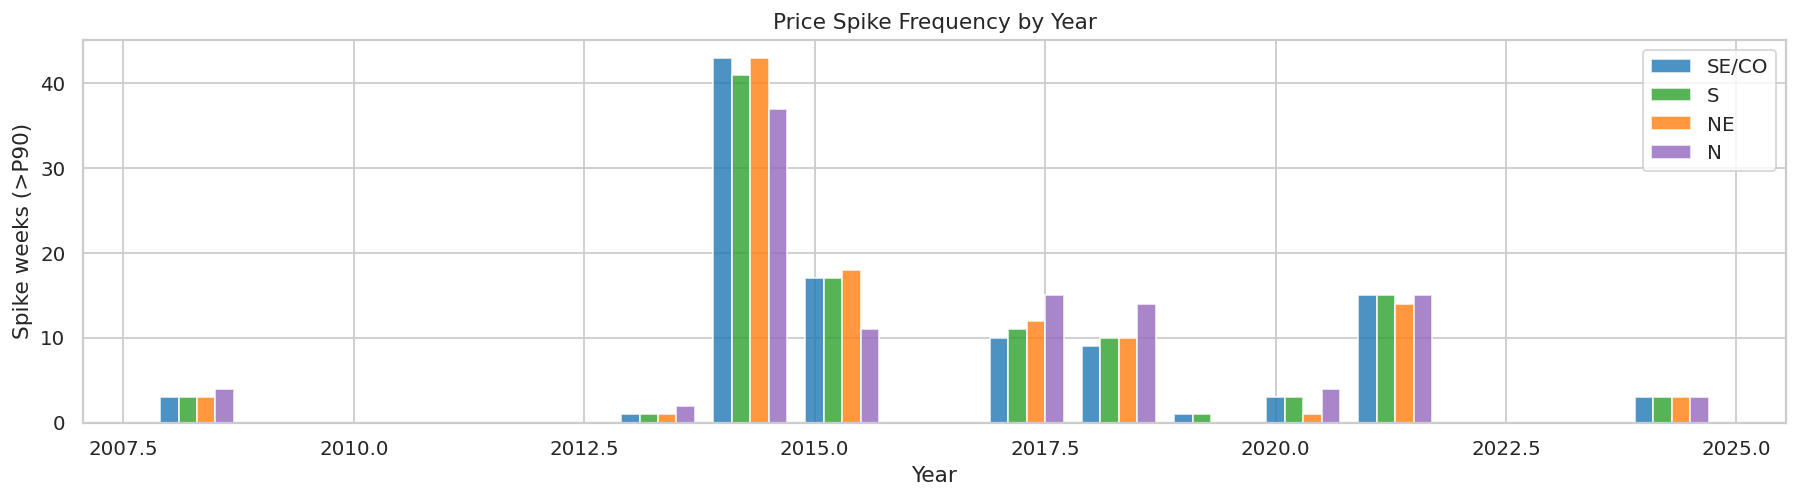

In [10]:
# Year-over-year spike frequency
spikes["year"] = pd.to_datetime(spikes["week_start"]).dt.year
spike_freq = spikes.groupby(["year", "subsystem"]).size().reset_index(name="n_spike_weeks")

fig, ax = plt.subplots(figsize=(14, 4))
for sub, color in zip(subsystems, colors):
    d = spike_freq[spike_freq["subsystem"] == sub]
    ax.bar(d["year"] + subsystems.index(sub) * 0.2, d["n_spike_weeks"],
           width=0.2, color=color, alpha=0.8, label=sub)

ax.set_xlabel("Year")
ax.set_ylabel("Spike weeks (>P90)")
ax.set_title("Price Spike Frequency by Year")
ax.legend()
plt.tight_layout()
plt.show()

## 6. Cross-Subsystem Correlation

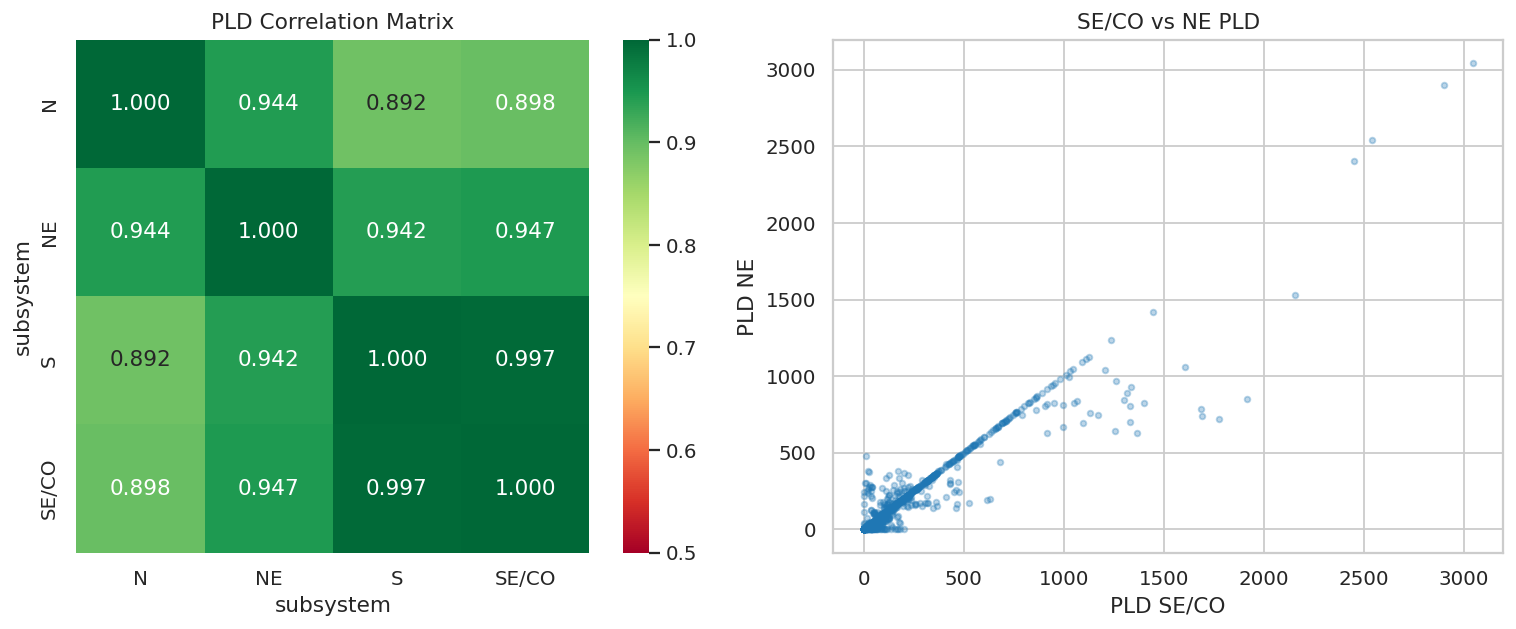


PLD spread (max - min across subsystems) by week:
count    1043.00
mean       57.10
std       146.62
min         0.00
25%         0.00
50%         2.69
75%        43.75
max      1485.44
Name: spread, dtype: float64


In [11]:
# Pivot to wide and compute correlation matrix
pld_wide = pld.pivot(index="week_start", columns="subsystem", values="pld_brl_mwh").dropna()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Correlation heatmap
corr = pld_wide.corr()
sns.heatmap(corr, annot=True, fmt=".3f", cmap="RdYlGn", vmin=0.5, vmax=1.0,
            ax=axes[0], square=True)
axes[0].set_title("PLD Correlation Matrix")

# Scatter: SE/CO vs NE (typically highest divergence)
axes[1].scatter(pld_wide["SE/CO"], pld_wide["NE"], alpha=0.3, s=10)
axes[1].set_xlabel("PLD SE/CO")
axes[1].set_ylabel("PLD NE")
axes[1].set_title("SE/CO vs NE PLD")

plt.tight_layout()
plt.show()

print("\nPLD spread (max - min across subsystems) by week:")
pld_wide["spread"] = pld_wide.max(axis=1) - pld_wide.min(axis=1)
print(pld_wide["spread"].describe().round(2))

## 7. Regulatory Bounds Context

The PLD is bounded by ANEEL/CMSE-set `PLD_min` and `PLD_max`, which change each year.

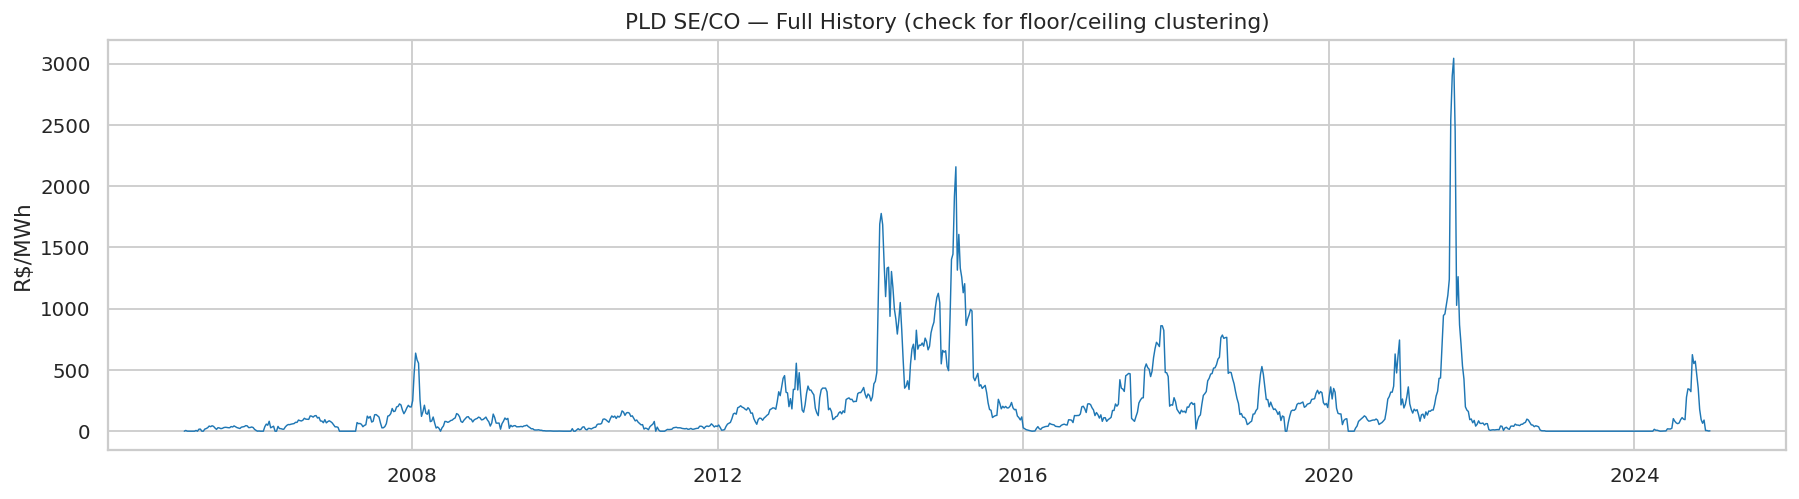

PLD value counts at bottom of distribution (potential floor hits):
pld_brl_mwh
0.00      109
0.01        3
136.81      2
81.37       2
61.39       2
36.20       2
133.41      2
0.08        2
0.52        2
72.01       2
Name: count, dtype: int64


In [12]:
# How often is PLD at the regulatory floor or ceiling?
# Approximate floor/ceiling (R$/MWh) — actual values published annually by ANEEL
# These are illustrative; update with actual values after running notebook 01

# Check distribution near extremes
fig, ax = plt.subplots(figsize=(14, 4))
seco_data = pld[pld["subsystem"] == "SE/CO"].sort_values("week_start")
ax.plot(seco_data["week_start"], seco_data["pld_brl_mwh"], linewidth=0.8)
ax.set_title("PLD SE/CO — Full History (check for floor/ceiling clustering)")
ax.set_ylabel("R$/MWh")
plt.tight_layout()
plt.show()

# Check value counts at extremes
print("PLD value counts at bottom of distribution (potential floor hits):")
print(pld[pld["subsystem"]=="SE/CO"]["pld_brl_mwh"].value_counts().head(10))